In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [118]:
df = pd.read_csv("netflix_titles.csv") # Loading csv file

In [119]:
df.head(10) # display first 10 rows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [97]:
df.shape

(8807, 12)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [120]:
df.drop_duplicates(subset='show_id', inplace=True)
df.drop(columns=['description'], inplace=True)
# duplicates dropped from original dataframe

In [ ]:
df.isnull().sum() #total count of NULL elements

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
dtype: int64

In [122]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('No Director Listed')
# NaN countries and directors replaced as asked

In [123]:
df['duration'] = df['duration'].fillna('0 min')
df['duration_minutes'] = 0
df['duration_seasons'] = 0

def split_duration(txt):
    splits = txt.split()
    value = int(splits[0])
    types = splits[1]
    if types[0] == 'm' or types[0] == 'M':
        return value, 0
    elif types[0] == 's' or types[0] == 'S':
        return 0, value
    else:
        return 0, 0
df[['duration_minutes', 'duration_seasons']] = (
    df['duration'].apply(lambda x: pd.Series(split_duration(x)))
)

# extracted season and minutes in separate columns using a basic python function


In [124]:
def is_recent(year):
    if year >= 2015:
        return 1
    else:
        return 0
df["Is_Recent"] = df["release_year"].apply(is_recent)
df[["release_year", "Is_Recent"]]

# binary feature for recent release check

,release_year,Is_Recent
0,2020,1
1,2021,1
2,2021,1
3,2021,1
4,2021,1
...,...,...
8802,2007,0
8803,2018,1
8804,2009,0
8805,2006,0


In [125]:
df['duration_minutes'] = df['duration_minutes'].replace(0, np.nan)
df['duration_seasons'] = df['duration_seasons'].replace(0, np.nan)
df.drop("duration",axis=1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,duration_minutes,duration_seasons,Is_Recent
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,Documentaries,90.0,NaN,1
1,s2,TV Show,Blood & Water,No Director Listed,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",NaN,2.0,1
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",NaN,1.0,1
3,s4,TV Show,Jailbirds New Orleans,No Director Listed,NaN,Unknown,"September 24, 2021",2021,TV-MA,"Docuseries, Reality TV",NaN,1.0,1
4,s5,TV Show,Kota Factory,No Director Listed,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",NaN,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,"Cult Movies, Dramas, Thrillers",158.0,NaN,0
8803,s8804,TV Show,Zombie Dumb,No Director Listed,NaN,Unknown,"July 1, 2019",2018,TV-Y7,"Kids' TV, Korean TV Shows, TV Comedies",NaN,2.0,1
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,"Comedies, Horror Movies",88.0,NaN,0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,"Children & Family Movies, Comedies",88.0,NaN,0


In [126]:
type_counts = df['type'].value_counts()
top_10_countries = df['country'].value_counts().head(10)

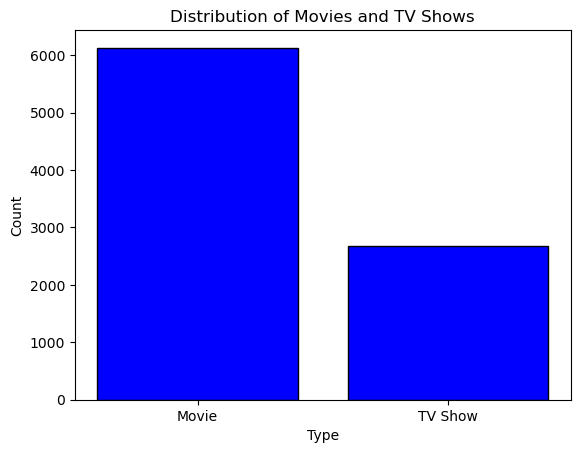

In [129]:
plt.bar(type_counts.index, type_counts.values, color='blue', edgecolor='black')
plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

# shows the comparison between the library count of the two type of content i.e. movies and TV shows by simple bar graph


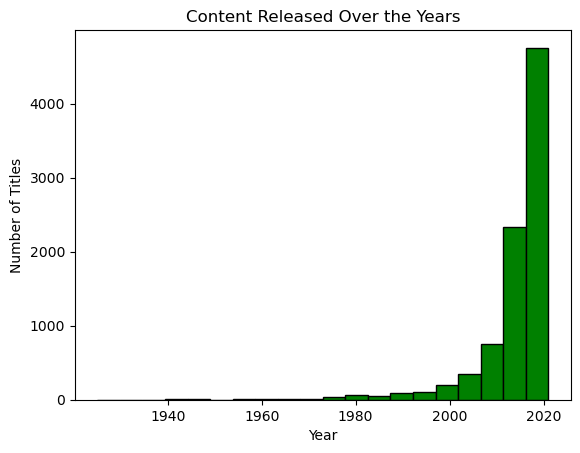

In [128]:
plt.hist(df['release_year'], bins=20, color='green', edgecolor='black')
plt.title('Content Released Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

# reveals the growth patterns and trends over time. displays the count of content released per year

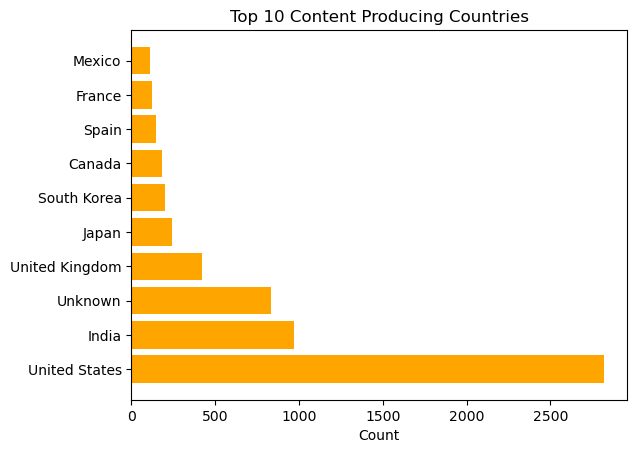

In [131]:
plt.barh(top_10_countries.index, top_10_countries.values, color='orange')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Count')
plt.show()

# This graph displays top 10 unique content producing countries.